In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.datasets import load_iris

In [265]:
ruido = np.random.uniform(-1000, 1000, 100)

X = np.linspace(1, 100, 100) # valor que vou fornecer ao modelo (features)
Y = X ** 2 + ruido # valor a ser previsto (target)

Y_true = X ** 2

In [266]:
atrubitos = X.reshape(-1, 1)
target = Y

In [267]:
train_f, test_f, train_t, test_t = train_test_split(atrubitos, target, test_size=0.2)

In [268]:
print(train_f.shape)
print(train_t.shape)
print(test_f.shape)
print(test_t.shape)

(80, 1)
(80,)
(20, 1)
(20,)


In [269]:
# Overfitting = quando o k for muito pequeno (1 ou 2)
# Underfitting = quando o k for muito alto (60% ou mais do número de amostras no conjunto de teste)
knn = KNeighborsRegressor(n_neighbors=5)
knn = knn.fit(train_f, train_t)

In [270]:
predicted = knn.predict(test_f)
predicted

array([2588.847184  , 2283.27141036, 3363.34885098, 3271.2480316 ,
        780.2282232 , 3331.6917867 , 9124.32653333, 2195.98720349,
       6708.14456574,  -49.31113095,  615.34444679, 9124.32653333,
       5432.03861759, 2983.80791258,  739.0217983 , 9124.32653333,
        575.96213842, 6570.26935842, 4360.42773755, 5430.12416068])

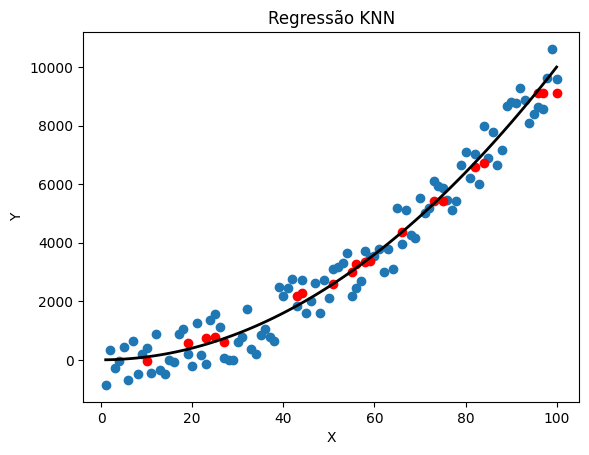

In [271]:
plt.scatter(X, Y)
plt.scatter(test_f, predicted, color='red')
plt.plot(X, Y_true, color='black', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regressão KNN')
plt.show()

In [272]:
mae = mean_absolute_error(test_t, predicted)
mse = mean_squared_error(test_t, predicted)

print(f'MAE: {mae}')
print(f'MSE: {mse}')

MAE: 567.0565233142927
MSE: 381031.56888323964


## Para evitar overfitting/underfitting...
utilizamos três diferentes fases no aprendizado de máquina:
* Fase de treinamento (training) -> Conjunto de treinamento
* Fase de seleção (selection) -> Conjunto de teste
* Fase de avaliação (assessment) -> Conjunto de validação

In [273]:
iris = load_iris()

train_f, test_f, train_t, test_t = train_test_split(iris.data, iris.target, train_size=0.6)
test_f, val_f, test_t, val_t = train_test_split(test_f, test_t, train_size=0.5)

In [274]:
best_k = -1
best_accuracy = -1

for k in range(1, 50):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn = knn.fit(train_f, train_t)
  previsoes_train = knn.predict(train_f)
  previsoes_test = knn.predict(test_f)
  acc_train = accuracy_score(previsoes_train, train_t)
  acc_test = accuracy_score(previsoes_test, test_t)
  print(f'Train accurancy: {acc_train}')
  print(f'Test accurancy: {acc_test}')

  if acc_test > best_accuracy:
    best_accuracy = acc_test
    best_k = k

Train accurancy: 1.0
Test accurancy: 0.9666666666666667
Train accurancy: 0.9666666666666667
Test accurancy: 0.9666666666666667
Train accurancy: 0.9666666666666667
Test accurancy: 0.9666666666666667
Train accurancy: 0.9666666666666667
Test accurancy: 0.9666666666666667
Train accurancy: 0.9777777777777777
Test accurancy: 0.9666666666666667
Train accurancy: 0.9666666666666667
Test accurancy: 0.9666666666666667
Train accurancy: 0.9666666666666667
Test accurancy: 0.9666666666666667
Train accurancy: 0.9555555555555556
Test accurancy: 0.9666666666666667
Train accurancy: 0.9666666666666667
Test accurancy: 0.9666666666666667
Train accurancy: 0.9666666666666667
Test accurancy: 0.9666666666666667
Train accurancy: 0.9777777777777777
Test accurancy: 0.9666666666666667
Train accurancy: 0.9555555555555556
Test accurancy: 0.9666666666666667
Train accurancy: 0.9555555555555556
Test accurancy: 0.9666666666666667
Train accurancy: 0.9444444444444444
Test accurancy: 0.9666666666666667
Train accurancy: 0.95

In [275]:
print(f'Melhor k: {best_k}')
print(f'Melhor acurácia: {best_accuracy}')

Melhor k: 28
Melhor acurácia: 1.0


In [276]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn = best_knn.fit(train_f, train_t)
previsoes_val = best_knn.predict(val_f)
acc_test = accuracy_score(previsoes_val, val_t)
print(f'Melhor acurácia: {acc_test}')

Melhor acurácia: 0.9333333333333333
